<div style="background:#161920;color:#F7FAFC;padding:30px 34px;border-radius:14px;border-top:5px solid #35B1B7;font-family:Arial,sans-serif">
<div style="color:#35B1B7;font-size:15px;letter-spacing:2px">ArtAICare Academy · SMALL DATA, BIG VISION</div>
<h1 style="color:#F7FAFC;margin-bottom:10px">The Object Finder</h1>
<p style="font-size:21px;color:#F9A212">Reuse a pretrained detector. Upload a photo. See what and where.</p>
<p>No training dataset. No training loop. No new classifier or box head.</p>
</div>

**Google Colab practical · YOLO11 Nano · classification + bounding-box localisation**

An image becomes learned visual features, candidate object predictions and labelled boxes. We first run a public demo, inspect edges and real early feature maps, then upload a new image from your computer.

**Read → predict → run → inspect → question.** Every cell is complete. The final Colab cell opens a file chooser and waits for your image; that pause is intentional.

### Start in Google Colab
1. Open [Google Colab](https://colab.research.google.com/), choose **File → Upload notebook**, and select this `.ipynb` file.
2. Keep a standard **CPU runtime**. A GPU is optional; the code uses CUDA if available.
3. Choose **Runtime → Run all**. Dependencies, official model weights and a public demo image download automatically. The first run needs internet; there is no API key, Drive mount or manual dataset download.
4. At **Section 12**, use **Choose files** to upload a JPG, PNG or WebP. The notebook displays labels, confidence scores and boxes, then saves the results.
5. To try another photo, rerun the final upload cell. To change confidence, edit `DISPLAY_CONFIDENCE` in that cell and rerun it.

The hosted Colab runtime/file chooser requires your browser and Google account. Local execution is verified separately; see `VERIFICATION.md` for what was actually tested. A local file cannot become a public one-click Colab URL without being hosted; the link above opens Colab's notebook upload flow.

| Route | Sections | Teaching time |
|---|---|---:|
| Core live demonstration | 1–6, then 12 | 20–30 minutes |
| Explain the visual features | 7–9 | 15–20 minutes |
| Group investigation | 10–12 | 25–35 minutes + presentations |

These are suggested teaching times, not model runtime benchmarks.

## 1. What are we transferring—and what are we not training?

Your previous art notebook used **ResNet18 with its final classifier removed**: an image became 512 features for similarity search. Here we keep a **complete pretrained object detector**, including its classification and bounding-box heads.

| Approach | What is reused? | Do we learn new weights here? |
|---|---|---|
| Previous art recommender | Fixed visual encoder; use its features for search | No |
| **This object finder** | **Backbone, feature-combination layers and trained detection heads** | **No—pretrained inference** |
| Frozen backbone + new classifier | Backbone is fixed; a new head is trained on target labels | Yes, the head |
| Fine-tuning | Selected pretrained layers and heads adapt to target labels | Yes |

This practical demonstrates **reuse of prior visual learning on new images**. More precisely, it performs pretrained inference, not target-domain training or fine-tuning. The weights do not learn from an uploaded photo.

**Why not attach just a fully connected layer?** A whole-image classifier says what category an image resembles. It does not automatically say where several objects are. A detector preserves spatial features and uses trained classification **and** box-prediction heads. YOLO11's detection head uses convolutional predictions; it is not simply ResNet's final fully connected classifier. Adding a new randomly initialised head without training would not solve localisation.

### Learning objectives
Distinguish classification, localisation, detection, segmentation and edges; load a small pretrained model; preserve its preprocessing contract; read pixel coordinates and confidence scores; inspect learned features; and evaluate successes/failures without confusing confidence with accuracy.

## 2. Which network fits the task?

| Family | Main output | Fit for this no-training lesson |
|---|---|---|
| FCN (2014 preprint / 2015 conference) | Semantic class per pixel | Choose for a segmentation lesson, not simple boxes |
| DeconvNet (2015) | Pixel-level semantic segmentation | More setup than we need |
| U-Net (2015) | Pixel-level segmentation; depends on the trained checkpoint | Useful for masks, not automatically an everyday-object detector |
| Fast R-CNN (2015) | Object classes and boxes using supplied region proposals | Historically useful, less convenient for this small practical |
| Faster R-CNN (2015; revised 2016) | Object classes and boxes, with learned proposals | Good detector alternative, usually heavier than a nano detector |
| Mask R-CNN (2017) | Object classes, boxes and instance masks | Choose when separate object outlines are required |
| YOLO (original 2015 preprint / CVPR 2016) | One-stage object detection | **Best fit here; use modern YOLO11 Nano weights** |

Dates refer to the original papers, with preprint/conference distinctions where relevant. YOLO11 is a later implementation in the YOLO family, not the 2016 network.

**Our choice: `yolo11n.pt`.** `n` means Nano. It is a compact COCO-pretrained checkpoint (roughly 5–6 MB) with 80 object categories. We record the actual loaded parameter count and file hash below. We select this established lightweight checkpoint for reproducibility, not because it is the newest YOLO release. [Model documentation](https://docs.ultralytics.com/models/yolo11/)

**Boxes are not outlines.** Object detection supplies rectangles. Segmentation assigns pixels; edge detection finds brightness changes without naming objects. The later Canny edge illustration is a separate algorithm, not a claim that YOLO returns exact boundaries.

## 3. Set up a reproducible Colab session

**What we do.** Install the tested detector package and import the small set of tools.

**Why.** Colab already provides PyTorch in normal runtimes; the package installer reuses compatible dependencies. No training data are required.

> **Predict before running:** Will loading a pretrained model change any of its learned weights?

In [2]:
# Install only missing packages (or the tested detector version) before importing them.
import importlib.util
import importlib.metadata
import subprocess
import sys
TESTED_ULTRALYTICS = "8.4.150"
needed = []
try:
    if importlib.metadata.version("ultralytics") != TESTED_ULTRALYTICS:
        needed.append(f"ultralytics=={TESTED_ULTRALYTICS}")
except importlib.metadata.PackageNotFoundError:
    needed.append(f"ultralytics=={TESTED_ULTRALYTICS}")
for module, package in {"pandas":"pandas", "matplotlib":"matplotlib", "PIL":"pillow", "ipywidgets":"ipywidgets"}.items():
    if importlib.util.find_spec(module) is None:
        needed.append(package)
if needed:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *needed])
print("Packages ready. No training data or API key needed.")

Packages ready. No training data or API key needed.


In [3]:
from pathlib import Path
import os, io, json, hashlib, time, shutil, platform
ROOT = Path.cwd()
DATA = ROOT / "data"
OUT = ROOT / "object_finder_results"
for folder in [DATA, OUT, ROOT/".config"/"Ultralytics", ROOT/".mplconfig"]:
    folder.mkdir(parents=True, exist_ok=True)
os.environ["YOLO_CONFIG_DIR"] = str(ROOT/".config")
os.environ["MPLCONFIGDIR"] = str(ROOT/".mplconfig")
os.environ["YOLO_AUTOINSTALL"] = "False"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from PIL import Image, ImageOps, UnidentifiedImageError
import cv2
import requests
import torch
import ultralytics
from ultralytics import YOLO, settings
from IPython.display import display, Markdown
settings.update({"sync": False})
torch.set_num_threads(min(4, torch.get_num_threads()))
DEVICE = 0 if torch.cuda.is_available() else "cpu"
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") is not None else False
BG, FG, TEAL, AMBER = "#161920", "#F7FAFC", "#35B1B7", "#F9A212"
COLORS = [TEAL, AMBER, "#B49FE0", "#F08C9D", "#A3CE82", "#79B9E8"]
plt.rcParams.update({"figure.facecolor":BG,"axes.facecolor":BG,"savefig.facecolor":BG,
    "text.color":FG,"axes.labelcolor":FG,"xtick.color":FG,"ytick.color":FG,
    "axes.edgecolor":"#556070","font.size":11,"figure.figsize":(11,6)})
RUN_RECORDS = []
print(f"Device: {DEVICE} | PyTorch {torch.__version__} | Ultralytics {ultralytics.__version__}")
print("Running in hosted Colab:", IN_COLAB)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/lenovo/dlh-modern_ai/deep_learning/transfer_learning/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device: cpu | PyTorch 2.14.0+cu130 | Ultralytics 8.4.150
Running in hosted Colab: False


## 4. Load the whole pretrained detector

**What we do.** Download the official YOLO11 Nano checkpoint automatically and load its existing heads.

**Why.** Prior COCO training supplies both category recognition and box localisation; there is no optimizer, backward pass or training loop.

> **Predict before running:** Will this detector recognise an arbitrary new category, such as a particular artist or bean variety?

In [4]:
MODEL_NAME = "yolo11n.pt"
MODEL_URL = "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt"
MODEL_PATH = ROOT / MODEL_NAME
# Same official checkpoint used by YOLO("yolo11n.pt"); explicit URL makes provenance visible.
def download_once(url, destination):
    destination = Path(destination)
    if destination.exists():
        return destination
    response = requests.get(url, timeout=(15, 120))
    response.raise_for_status()
    temporary = destination.with_suffix(destination.suffix + ".download")
    temporary.write_bytes(response.content)
    temporary.replace(destination)
    return destination

download_once(MODEL_URL, MODEL_PATH)
detector = YOLO(str(MODEL_PATH))
detector.model.eval()
detector.model.requires_grad_(False)
CATEGORIES = detector.names
MODEL_SHA256 = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
print("Loaded:", MODEL_NAME)
print("Checkpoint size (MiB):", round(MODEL_PATH.stat().st_size / 1024**2, 2))
print("Parameters:", f"{sum(p.numel() for p in detector.model.parameters()):,}")
print("Trained object categories:", len(CATEGORIES))
print("Trainable parameters:", sum(p.numel() for p in detector.model.parameters() if p.requires_grad))
assert len(CATEGORIES) == 80
print(", ".join(CATEGORIES.values()))

Loaded: yolo11n.pt
Checkpoint size (MiB): 5.35
Parameters: 2,624,080
Trained object categories: 80
Trainable parameters: 0
person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe, backpack, umbrella, handbag, tie, suitcase, frisbee, skis, snowboard, sports ball, kite, baseball bat, baseball glove, skateboard, surfboard, tennis racket, bottle, wine glass, cup, fork, knife, spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake, chair, couch, potted plant, bed, dining table, toilet, tv, laptop, mouse, remote, keyboard, cell phone, microwave, oven, toaster, sink, refrigerator, book, clock, vase, scissors, teddy bear, hair drier, toothbrush


**The vocabulary matters.** COCO includes objects such as person, bicycle, car, bus, dog, cat, bottle and chair. It does not provide arbitrary new categories. A wine bottle might be labelled “bottle”; a bean variety or a particular painting style is not something this checkpoint was trained to identify. No detection does not prove absence.

The image is processed by the model inside your runtime. In Colab, uploaded bytes go to your Colab session. This notebook does not call a paid image-recognition API or upload the image to a model hosting service. We use `eval()` and `torch.inference_mode()`; freezing parameters makes the no-training intent explicit.

**Preprocessing contract:** give Ultralytics a correctly oriented RGB PIL image. Its predictor handles letterbox resizing/padding, tensor conversion and scaling to [0,1]. Do **not** apply the art notebook's 224×224 centre crop or ImageNet channel normalisation here. Detection needs the whole image and its spatial geometry. [Prediction documentation](https://docs.ultralytics.com/modes/predict/)

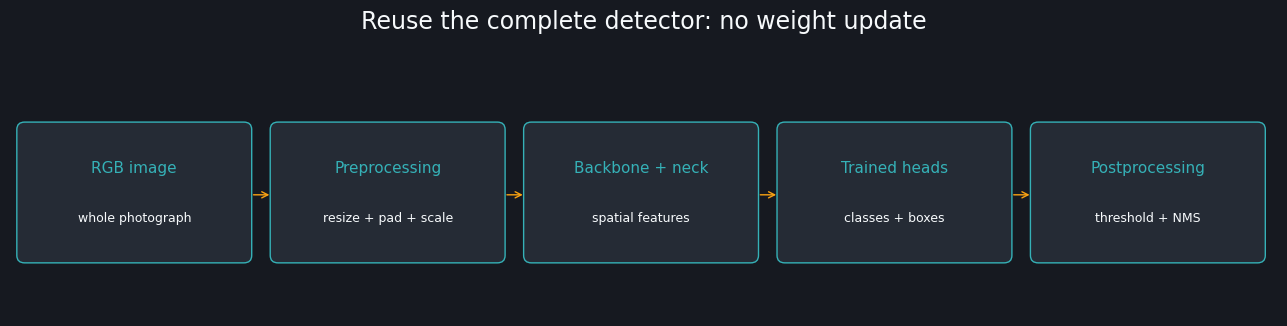

In [5]:
# A conceptual pipeline, not a layer-by-layer reconstruction of the network.
fig, ax = plt.subplots(figsize=(13, 3.4)); ax.set(xlim=(0, 13), ylim=(0, 3)); ax.axis("off")
steps = [("RGB image", "whole photograph"), ("Preprocessing", "resize + pad + scale"),
         ("Backbone + neck", "spatial features"), ("Trained heads", "classes + boxes"),
         ("Postprocessing", "threshold + NMS")]
for i, (title, detail) in enumerate(steps):
    x = .15 + i*2.6
    ax.add_patch(FancyBboxPatch((x,.65),2.25,1.35,boxstyle="round,pad=.08",facecolor="#252B35",edgecolor=TEAL))
    ax.text(x+1.125,1.55,title,ha="center",fontsize=11,color=TEAL)
    ax.text(x+1.125,1.02,detail,ha="center",fontsize=9)
    if i<4: ax.annotate("",xy=(x+2.54,1.3),xytext=(x+2.32,1.3),arrowprops={"arrowstyle":"->","color":AMBER})
ax.set_title("Reuse the complete detector: no weight update",fontsize=17)
plt.tight_layout();plt.savefig(OUT/"pipeline.png",dpi=160,bbox_inches="tight");plt.show();plt.close()

## 5. Detect objects in the automatic demo

**What we do.** Run one public example and display the same image with predicted boxes.

**Why.** The demo confirms the pipeline works before anyone selects a personal image.

> **Predict before running:** Which objects can you name, and which small or partly hidden ones might the model miss?

Demo image: (810, 1080) pixels | RGB
Source: Ultralytics public demonstration image https://raw.githubusercontent.com/ultralytics/assets/main/im/bus.jpg


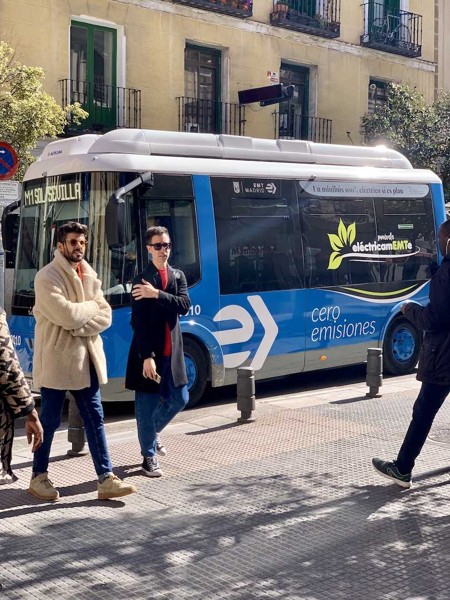

In [6]:
DEMO_URL = "https://raw.githubusercontent.com/ultralytics/assets/main/im/bus.jpg"
DEMO_PATH = download_once(DEMO_URL, DATA/"bus.jpg")

def read_image_bytes(content):
    """Decode, correct EXIF orientation, and composite transparency on white."""
    with Image.open(io.BytesIO(content)) as source:
        source.load()
        oriented = ImageOps.exif_transpose(source)
        if oriented.mode in ("RGBA", "LA") or (oriented.mode == "P" and "transparency" in oriented.info):
            rgba = oriented.convert("RGBA")
            background = Image.new("RGBA", rgba.size, "white")
            return Image.alpha_composite(background, rgba).convert("RGB")
        return oriented.convert("RGB")

demo_image = read_image_bytes(DEMO_PATH.read_bytes())
print("Demo image:", demo_image.size, "pixels |", demo_image.mode)
print("Source: Ultralytics public demonstration image", DEMO_URL)
display(demo_image.resize((450, round(demo_image.height*450/demo_image.width))))

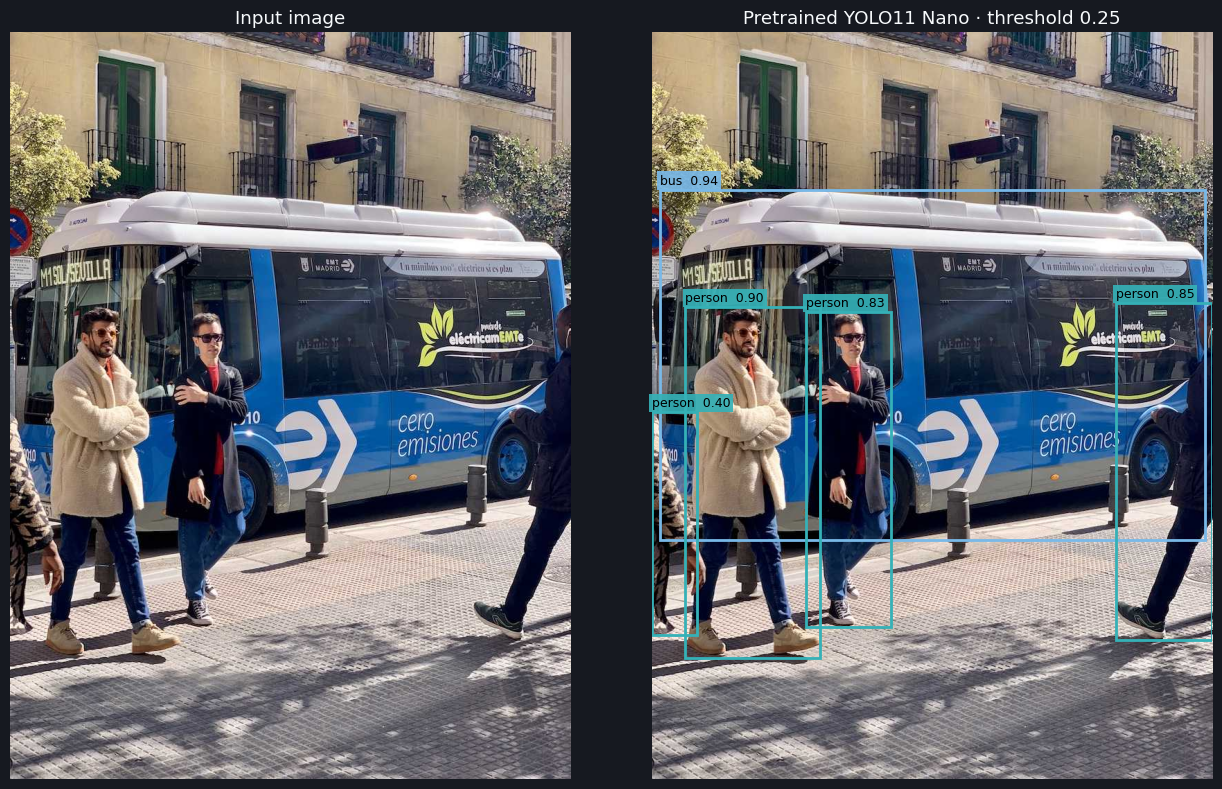

,class_id,object,confidence,x_min,y_min,x_max,y_max,width,height
0,5,bus,0.939,11.918,228.394,799.225,735.215,787.307,506.821
1,0,person,0.902,48.593,397.961,243.213,904.536,194.620,506.575
2,0,person,0.849,670.556,392.590,810.000,879.623,139.444,487.033
3,0,person,0.833,223.120,405.578,345.229,859.722,122.109,454.144
4,0,person,0.399,0.000,550.193,66.008,871.779,66.008,321.586


In [7]:
IMAGE_SIZE = 640
RAW_CONFIDENCE = 0.05
NMS_IOU = 0.45
MAX_DETECTIONS = 100
COLUMNS = ["class_id", "object", "confidence", "x_min", "y_min", "x_max", "y_max", "width", "height"]

def detect_image(image):
    """Inference only. Coordinates returned by Ultralytics refer to the supplied upright image."""
    with torch.inference_mode():
        result = detector.predict(source=image, imgsz=IMAGE_SIZE, conf=RAW_CONFIDENCE,
            iou=NMS_IOU, max_det=MAX_DETECTIONS, device=DEVICE, rect=False, verbose=False)[0]
    records = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].detach().cpu().tolist()
        class_id = int(box.cls.item())
        records.append({"class_id":class_id,"object":CATEGORIES[class_id],
            "confidence":float(box.conf.item()),"x_min":x1,"y_min":y1,"x_max":x2,"y_max":y2,
            "width":x2-x1,"height":y2-y1})
    table = pd.DataFrame(records, columns=COLUMNS)
    if not table.empty:
        table = table.sort_values("confidence", ascending=False).reset_index(drop=True)
    return table, result

def keep_confident(table, threshold):
    if not RAW_CONFIDENCE <= threshold <= 1:
        raise ValueError(f"Choose a threshold between {RAW_CONFIDENCE} and 1.")
    return table.loc[table.confidence.ge(threshold)].copy().reset_index(drop=True)

def draw_boxes(ax, image, table, title):
    ax.imshow(image)
    for row in table.itertuples(index=False):
        color = COLORS[int(row.class_id)%len(COLORS)]
        ax.add_patch(Rectangle((row.x_min,row.y_min),row.width,row.height,
                               fill=False,edgecolor=color,linewidth=2))
        ax.text(row.x_min, max(0,row.y_min-4),f"{row.object}  {row.confidence:.2f}",
                color="black",fontsize=9,va="bottom",bbox={"facecolor":color,"alpha":.92,"pad":2,"edgecolor":"none"})
    ax.set(xlim=(0,image.width),ylim=(image.height,0),title=title)
    ax.axis("off")
    if table.empty:
        ax.text(.5,.04,"No detections above this threshold",transform=ax.transAxes,ha="center",
                bbox={"facecolor":BG,"alpha":.9,"edgecolor":"none"},color=FG)

def show_detection(image, table, title, destination=None):
    fig, axes = plt.subplots(1,2,figsize=(13,8))
    axes[0].imshow(image); axes[0].axis("off"); axes[0].set_title("Input image")
    draw_boxes(axes[1],image,table,title)
    plt.tight_layout()
    if destination is not None:fig.savefig(destination,dpi=160,bbox_inches="tight")
    plt.show();plt.close(fig)
    display(table.round(3))

demo_raw, demo_result = detect_image(demo_image)
demo_table = keep_confident(demo_raw, .25)
show_detection(demo_image,demo_table,"Pretrained YOLO11 Nano · threshold 0.25",OUT/"demo_detection.png")
demo_table.to_csv(OUT/"demo_detections.csv",index=False)
# The library may initialise/fuse inference layers on first use. Snapshot AFTER warm-up.
inference_network = detector.predictor.model.model
inference_network.requires_grad_(False)
def weight_fingerprint():
    digest = hashlib.sha256()
    for name, value in inference_network.state_dict().items():
        digest.update(name.encode()); digest.update(value.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()
FROZEN_WEIGHTS = weight_fingerprint()

## 6. Read what and where

**What we do.** Interpret the result table and change only the confidence display threshold.

**Why.** A box is a geometric prediction; a confidence score is not a measured percentage accuracy.

> **Predict before running:** Will increasing the threshold improve accuracy, or only remove lower-scoring predictions?

A detection consists of an **object category**, a **confidence score**, and **`(x_min, y_min, x_max, y_max)`**. The image origin is the top-left corner: x increases rightwards, y downwards. Width is `x_max − x_min`; height is `y_max − y_min`. Coordinates refer to the upright input image, not the 640-pixel padded model input.

**Confidence filtering** hides scores below a chosen threshold. A higher threshold usually displays fewer boxes; it does not improve the learned model or establish accuracy. Precision/recall need manually verified objects and a matching rule; mAP needs a labelled evaluation set. One attractive photo is not a benchmark.

**NMS (non-maximum suppression)** removes sufficiently overlapping, lower-scoring candidates for the same class. Its IoU threshold is different from a confidence threshold. We fix NMS IoU at 0.45 and cap output at 100 detections. The plots below filter the **same post-NMS candidate set**—no retraining and no repeated model inference. Candidates below the initial 0.05 cutoff are already absent.

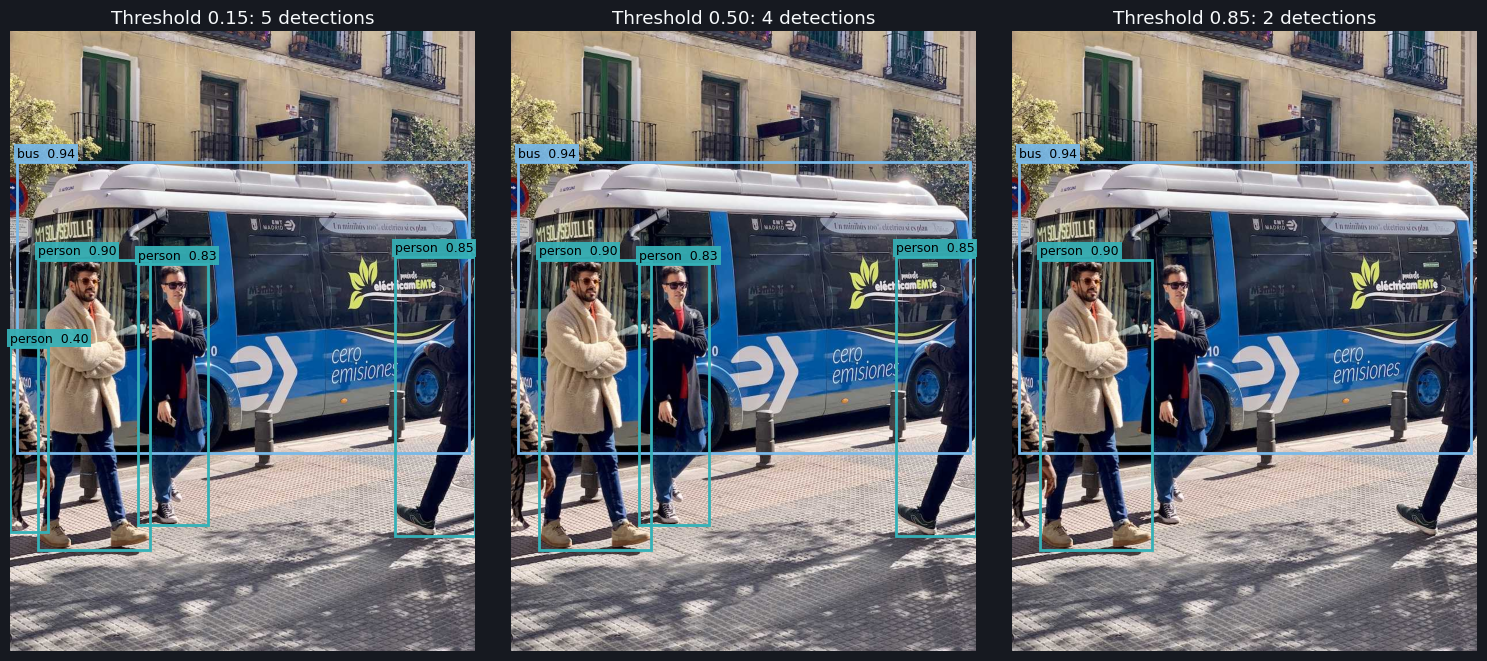

,threshold,detections
0,0.15,5
1,0.50,4
2,0.85,2


Example: bus, width=787.3px, height=506.8px.


In [8]:
threshold_rows = []
fig, axes = plt.subplots(1,3,figsize=(15,7))
for ax, threshold in zip(axes,[.15,.50,.85]):
    visible = keep_confident(demo_raw,threshold)
    draw_boxes(ax,demo_image,visible,f"Threshold {threshold:.2f}: {len(visible)} detections")
    threshold_rows.append({"threshold":threshold,"detections":len(visible)})
plt.tight_layout();plt.savefig(OUT/"confidence_comparison.png",dpi=150,bbox_inches="tight");plt.show();plt.close()
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table);threshold_table.to_csv(OUT/"threshold_comparison.csv",index=False)
if not demo_table.empty:
    example=demo_table.iloc[0]
    print(f"Example: {example['object']}, width={example['width']:.1f}px, height={example['height']:.1f}px.")

## 7. Edges are not object identities

**What we do.** Compare the RGB photo, a classical Canny edge map, and predicted object boxes.

**Why.** The word “edge” means a local brightness boundary, which is different from an object class or its exact silhouette.

> **Predict before running:** Will every visible edge form a meaningful object boundary?

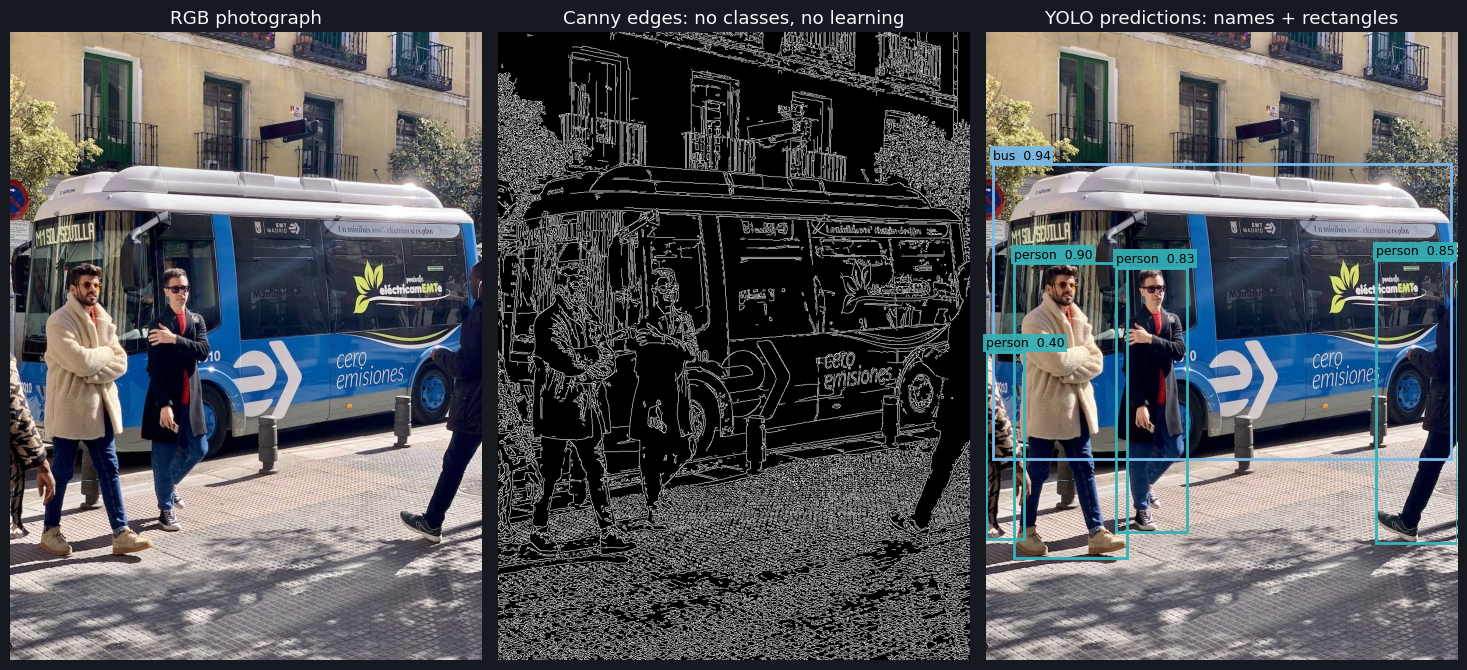

In [9]:
gray = cv2.cvtColor(np.asarray(demo_image),cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray,80,160)
fig, axes = plt.subplots(1,3,figsize=(15,7))
axes[0].imshow(demo_image);axes[0].set_title("RGB photograph");axes[0].axis("off")
axes[1].imshow(edges,cmap="gray");axes[1].set_title("Canny edges: no classes, no learning");axes[1].axis("off")
draw_boxes(axes[2],demo_image,demo_table,"YOLO predictions: names + rectangles")
plt.tight_layout();plt.savefig(OUT/"edges_vs_detection.png",dpi=150,bbox_inches="tight");plt.show();plt.close()

**Observe:** windows, shadows, lettering and texture all create edges. A box can enclose much background and does not trace an object outline. Canny is not a preprocessing input to YOLO in this notebook: the detector still receives the RGB photograph. For pixel masks, use a segmentation checkpoint rather than renaming these rectangles “segmentation.”

## 8. Inspect actual early learned feature maps

**What we do.** Capture activations from the first feature block during a real detector forward pass.

**Why.** This connects the “encoder and head” slide to concrete spatial features before the detection head.

> **Predict before running:** Will each feature channel be a clean edge detector with an obvious human name?

Actual model input (channels, height, width): (3, 640, 640)
First block output (channels, height, width): (16, 320, 320)


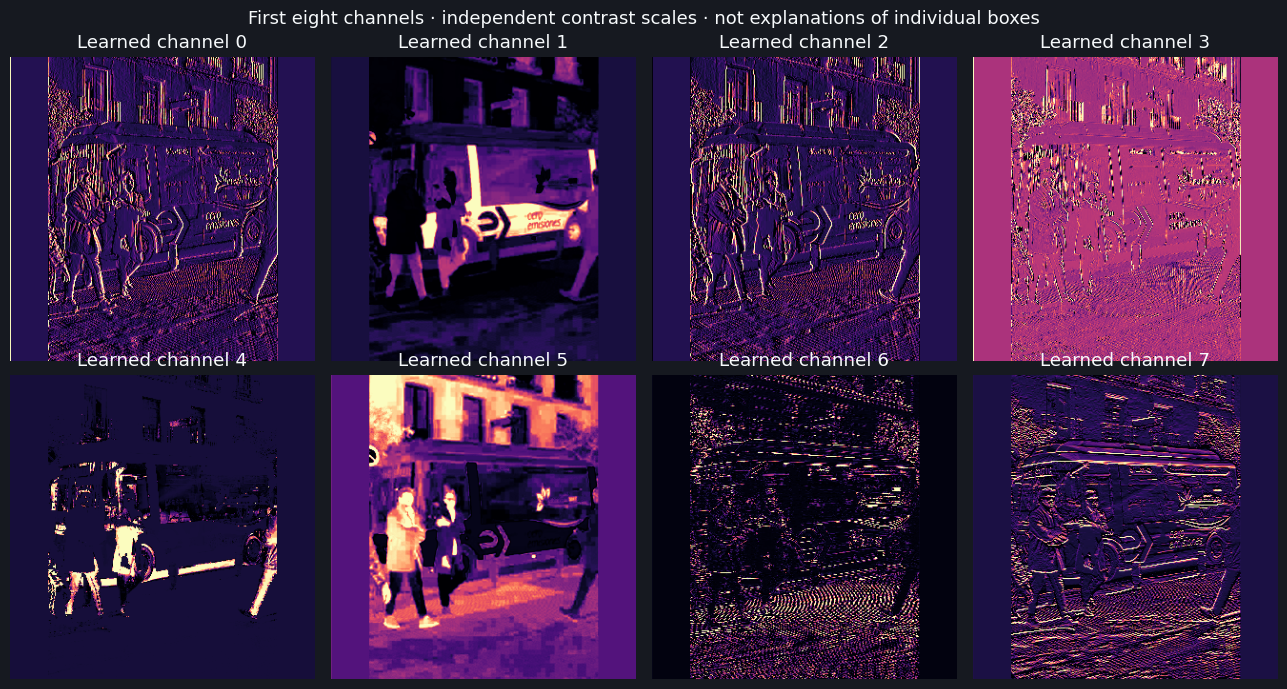

Learned state unchanged after observation: True


In [10]:
# A hook observes the existing model; it does not alter its weights or replace its head.
captured = {}
def capture_first_block(module, inputs, output):
    captured["input"] = inputs[0].detach().cpu()[0].clone()
    captured["features"] = output.detach().cpu()[0].clone()
hook = inference_network.model[0].register_forward_hook(capture_first_block)
try:
    _observed_table, _ = detect_image(demo_image)
finally:
    hook.remove()
assert "features" in captured
feature_maps = captured["features"].numpy()
print("Actual model input (channels, height, width):",tuple(captured["input"].shape))
print("First block output (channels, height, width):",feature_maps.shape)
fig, axes = plt.subplots(2,4,figsize=(13,7))
for channel, ax in enumerate(axes.flat):
    feature=feature_maps[channel]
    low,high=np.percentile(feature,[2,98])
    ax.imshow(feature,cmap="magma",vmin=low,vmax=high if high>low else low+1e-6)
    ax.set_title(f"Learned channel {channel}");ax.axis("off")
fig.suptitle("First eight channels · independent contrast scales · not explanations of individual boxes",fontsize=13)
plt.tight_layout();plt.savefig(OUT/"early_feature_maps.png",dpi=160,bbox_inches="tight");plt.show();plt.close()
assert weight_fingerprint()==FROZEN_WEIGHTS
print("Learned state unchanged after observation:",True)

These are actual activations from the loaded detector, not an invented illustration. We show channels 0–7 without selecting them for a preferred story. Each panel uses its own contrast scale, so brightness cannot rank importance across channels. Features contain responses to edges, textures and combinations; a particular channel is not guaranteed to mean “wheel” or “person.” Padding is part of the model's spatial input. This display is **not saliency, Grad-CAM or a causal explanation** of a predicted box.

## 9. Test a change to the image

**What we do.** Reduce the demo image resolution and enlarge it back, then detect again with unchanged settings.

**Why.** The same learned model can behave differently when visual evidence changes.

> **Predict before running:** Which small details might disappear, and could a wrong prediction gain confidence?

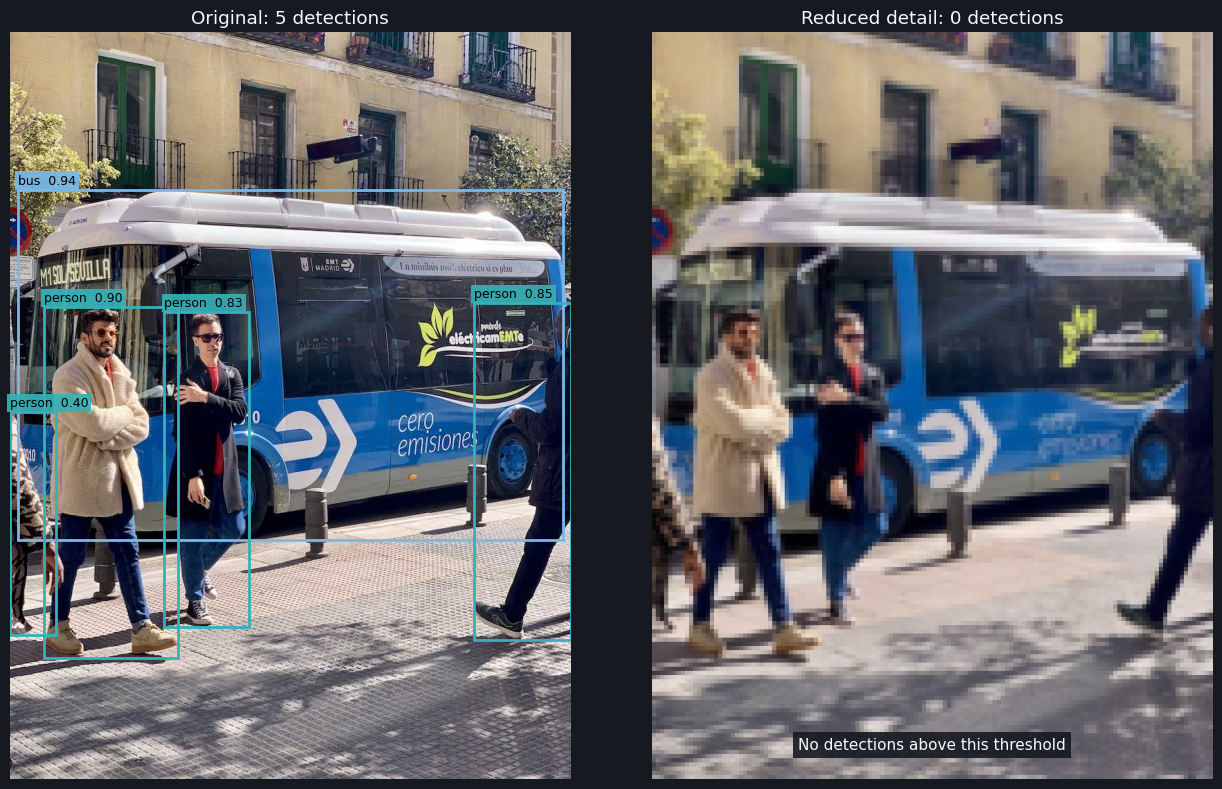

,condition,detections
0,original,5
1,reduced_detail,0


In [11]:
small = demo_image.resize((max(1,demo_image.width//6),max(1,demo_image.height//6)),Image.Resampling.BILINEAR)
degraded = small.resize(demo_image.size,Image.Resampling.NEAREST)
degraded_raw,_=detect_image(degraded);degraded_table=keep_confident(degraded_raw,.25)
fig, axes = plt.subplots(1,2,figsize=(13,8))
draw_boxes(axes[0],demo_image,demo_table,f"Original: {len(demo_table)} detections")
draw_boxes(axes[1],degraded,degraded_table,f"Reduced detail: {len(degraded_table)} detections")
plt.tight_layout();plt.savefig(OUT/"image_detail_experiment.png",dpi=160,bbox_inches="tight");plt.show();plt.close()
detail_table=pd.DataFrame([{"condition":"original","detections":len(demo_table)},
                           {"condition":"reduced_detail","detections":len(degraded_table)}])
display(detail_table);detail_table.to_csv(OUT/"image_detail_experiment.csv",index=False)
assert weight_fingerprint()==FROZEN_WEIGHTS

**Interpret the actual output:** compare object identities, locations and confidence—not only counts. The same number of boxes can hide different errors. This is a controlled change in image detail, not an accuracy measurement or proof about all blurred images. Paintings, cartoons and unusual viewpoints can shift the image domain even more. The art recommender's success would not establish object-detection performance on paintings.

## 10. Group task: one model, one changed factor

Work in teams of 3–4 for 25–35 minutes. Roles: operator, observer, sceptic and presenter. Use at least two images and choose **one** investigation:

| Team question | Keep fixed | Change and record |
|---|---|---|
| Confidence | Image, model, input size, NMS | Threshold 0.15, 0.50, 0.85; count and inspect boxes |
| Image detail | Image scene, model, settings | Downsample/restore resolution; inspect small objects |
| Occlusion/viewpoint | Model/settings; similar object category | A clear versus partly hidden/viewpoint-changed example |
| Domain shift | Model/settings; similar object category | A photograph versus a drawing/painting |
| Vocabulary limits | Model/settings | A supported everyday object versus a specialised object |

**Submission:** two annotated images, one detection CSV, a short observation table and a five-minute presentation. Record image source, dimensions, model, confidence, NMS and input size. Identify at least one success, one missed/wrong detection or ambiguous case, one limitation and one next test. More detections is not automatically better.

**Optional quantitative extension:** hand-label objects in a few images, define category agreement and IoU ≥ 0.5, use one-to-one matching, and count true positives, false positives and false negatives. State the tiny sample size; do not call a detector's confidence its accuracy. Annotating evaluation images is not retraining.

**Five-minute presentation:** question (40 s), fixed/changed conditions (60 s), actual results (90 s), limitations (60 s), next experiment (50 s).

**Rubric (20):** clear comparison 5; actual image/box evidence 5; correct interpretation 5; useful next test 5. Do not reward the highest detection count.

<details><summary><strong>Instructor debrief: suggested answers</strong></summary>

- Uploading a photo performs inference; it does not fine-tune the weights.
- A new randomly initialised head needs labelled training; replacing only the class list is insufficient.
- A global fully connected classifier is not a multi-object detector.
- A high confidence can still be wrong. An undetected object can still be present.
- A stricter threshold removes lower-scoring candidates; it does not learn better features.
- Canny edges, learned feature maps, bounding boxes and masks are different outputs.
- If the image contains an unsupported category, use a suitably trained checkpoint or collect labels for a future adaptation exercise.
- Feature maps are not explanations of which pixels caused a specific detection.

</details>

## 11. Prepare the upload-and-detect action

**What we do.** Use one function for uploaded bytes, annotation, tables and exports.

**Why.** The same preprocessing/prediction path handles the demo and new inputs; invalid files or cancellation should not break the lesson.

> **Predict before running:** What should the program report if no box survives the threshold?

In [12]:
def save_bundle():
    # Exports contain only files produced by this notebook, not unrelated runtime files.
    return Path(shutil.make_archive(str(ROOT/"object_finder_results"),"zip",root_dir=OUT))

def process_uploads(uploaded, threshold=.25):
    """Accept a filename->bytes mapping, as returned by google.colab.files.upload()."""
    if not uploaded:
        print("No image selected. Rerun the upload cell whenever you are ready.")
        return []
    processed=[]
    for filename, content in uploaded.items():
        try:
            image=read_image_bytes(bytes(content))
        except (UnidentifiedImageError,OSError,ValueError,ImportError) as exc:
            print(f"Could not read {filename!r} as an image. Choose a JPG, PNG or WebP. ({type(exc).__name__})")
            continue
        safe_id=hashlib.sha256(bytes(content)).hexdigest()[:12]
        raw,result=detect_image(image);visible=keep_confident(raw,threshold)
        title=f"Uploaded image · threshold {threshold:.2f} · {len(visible)} detections"
        show_detection(image,visible,title,OUT/f"upload_{safe_id}_comparison.png")
        # Standalone annotated image at the original upright resolution.
        selected_result=result[result.boxes.conf >= threshold]
        annotated_bgr=selected_result.plot(conf=True,labels=True)
        Image.fromarray(annotated_bgr[..., ::-1]).save(OUT/f"upload_{safe_id}_annotated.png")
        visible.to_csv(OUT/f"upload_{safe_id}_detections.csv",index=False)
        record={"source_name":str(filename),"image_id":safe_id,"width":image.width,"height":image.height,
                "threshold":threshold,"detections":len(visible),"model":MODEL_NAME}
        RUN_RECORDS.append(record);processed.append(record)
        print("Box coordinates refer to the upright input image:",image.size)
        if visible.empty:print("No detections above the threshold. This does not prove that the image contains no objects.")
    (OUT/"uploaded_image_runs.json").write_text(json.dumps(RUN_RECORDS,indent=2))
    assert weight_fingerprint()==FROZEN_WEIGHTS
    archive=save_bundle();print("Saved results:",archive.name)
    return processed

manifest={"model":MODEL_NAME,"model_url":MODEL_URL,"model_sha256":MODEL_SHA256,
    "source_demo":DEMO_URL,"demo_sha256":hashlib.sha256(DEMO_PATH.read_bytes()).hexdigest(),
    "torch":torch.__version__,"ultralytics":ultralytics.__version__,"python":platform.python_version(),
    "device":str(DEVICE),"input_size":IMAGE_SIZE,"raw_confidence":RAW_CONFIDENCE,"NMS_IoU":NMS_IOU,
    "max_detections":MAX_DETECTIONS,"demo_threshold":.25,"demo_detections":demo_table.to_dict(orient="records"),
    "threshold_experiment":threshold_rows,"detail_experiment":detail_table.to_dict(orient="records"),
    "first_feature_shape":list(feature_maps.shape),"learned_state_unchanged":weight_fingerprint()==FROZEN_WEIGHTS,
    "training_performed":False,"hosted_colab_session":IN_COLAB}
(OUT/"run_manifest.json").write_text(json.dumps(manifest,indent=2))
save_bundle()
print("Demo complete. The next cell is the image-upload step.")

Demo complete. The next cell is the image-upload step.


### Source notes and reading

- Complete checkpoint, supported tasks and usage: [Ultralytics YOLO11](https://docs.ultralytics.com/models/yolo11/), [prediction/results API](https://docs.ultralytics.com/modes/predict/), [COCO categories](https://docs.ultralytics.com/datasets/detect/coco/). Model/software terms: [Ultralytics licence information](https://www.ultralytics.com/license). Demo image: [Ultralytics assets](https://github.com/ultralytics/assets).
- Architecture history: [FCN](https://arxiv.org/abs/1411.4038), [DeconvNet](https://arxiv.org/abs/1505.04366), [U-Net](https://arxiv.org/abs/1505.04597), [Fast R-CNN](https://arxiv.org/abs/1504.08083), [Faster R-CNN](https://arxiv.org/abs/1506.01497), [Mask R-CNN](https://arxiv.org/abs/1703.06870), [original YOLO](https://arxiv.org/abs/1506.02640).
- File upload: [Google Colab I/O notebook](https://colab.research.google.com/notebooks/io.ipynb).

This lesson follows the supplied *Small Data, Big Vision* distinction between fixed feature reuse, head training and fine-tuning, and the art notebook's read/run/inspect style. It does not reuse paintings as a labelled detection benchmark.

## 12. Your turn: upload an image from your computer

**What we do.** Open Colab’s file chooser, upload one or more images, and automatically detect and save results.

**Why.** New photos test the pretrained model without changing it.

> **Predict before running:** Write down the objects you expect before choosing the file. Which belong to the supported vocabulary?

**Run this cell.** In Colab, click **Choose files**, select your JPG/PNG/WebP and wait for the annotated image and table. Cancel if you do not want to upload now. Rerun this cell for another photo. For a clear first test, use a photo with everyday objects such as a person, bicycle, bottle, chair or dog.

`DISPLAY_CONFIDENCE` controls what is displayed; the weights remain fixed. If you are using the normal Jupyter application instead, an Upload button appears below. Uploads in either interface call the same tested processing function.

**Keep results:** the Colab Files sidebar contains `object_finder_results.zip`; right-click it and choose **Download**. It contains annotated figures, detection CSVs, experiments and model provenance. The ZIP refreshes after each upload. The runtime is temporary, so download the results you want to keep.

In [18]:
DISPLAY_CONFIDENCE = 0.05   # Experiment with 0.15, 0.50 or 0.85; no training occurs.

if IN_COLAB:
    from google.colab import files
    uploaded = files.upload()  # Native Colab file chooser; waits for the student's selection.
    uploaded_results = process_uploads(uploaded, threshold=DISPLAY_CONFIDENCE)
else:
    import ipywidgets as widgets
    uploader = widgets.FileUpload(accept="image/*",multiple=True,description="Upload image")
    upload_output = widgets.Output()
    def on_upload(change):
        value=change["new"]
        # Support ipywidgets 7 dictionaries and ipywidgets 8 tuple-of-records.
        payload=({name:entry["content"] for name,entry in value.items()} if isinstance(value,dict)
                 else {entry["name"]:entry["content"] for entry in value})
        with upload_output:
            upload_output.clear_output(wait=True)
            process_uploads(payload,threshold=DISPLAY_CONFIDENCE)
    uploader.observe(on_upload,names="value")
    display(widgets.VBox([uploader,upload_output]))
    print("Local Jupyter upload button ready. Colab uses its native Choose files button instead.")

Local Jupyter upload button ready. Colab uses its native Choose files button instead.
